Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 241MB/s]

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.7303 - loss: 0.5508
Epoch 1: val_accuracy improved from None to 0.88747, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 144s 903ms/step - accuracy: 0.8097 - loss: 0.4040 - val_accuracy: 0.8875 - val_loss: 0.2526 - learning_rate: 1.0000e-04
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.8984 - loss: 0.2438
Epoch 2: val_accuracy improved from 0.88747 to 0.91688, saving model to best_mobilenet_model.keras

Epoch 2: finished saving model to best_mobilenet_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 97s 696ms/step - accuracy: 0.9010 - loss: 0.2301 - val_accuracy: 0.9169 - val_loss: 0.1925 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9121 - loss: 0.2174
Epoch 3: val_accuracy improved from 0.91688 to 0.92327, saving model to best_mobilenet_model.keras

Epoch 3: finished sa

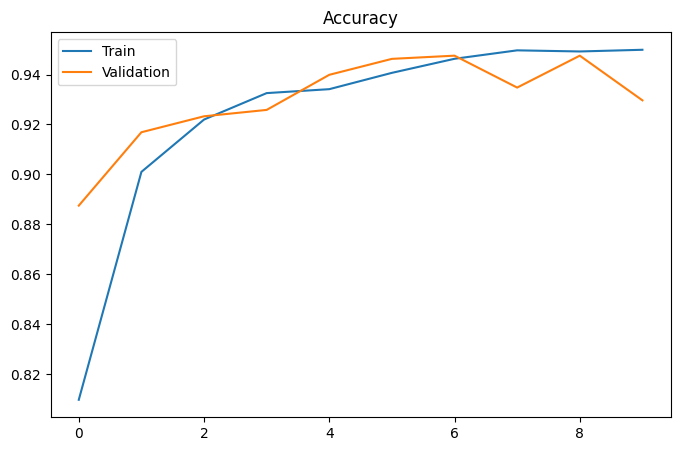

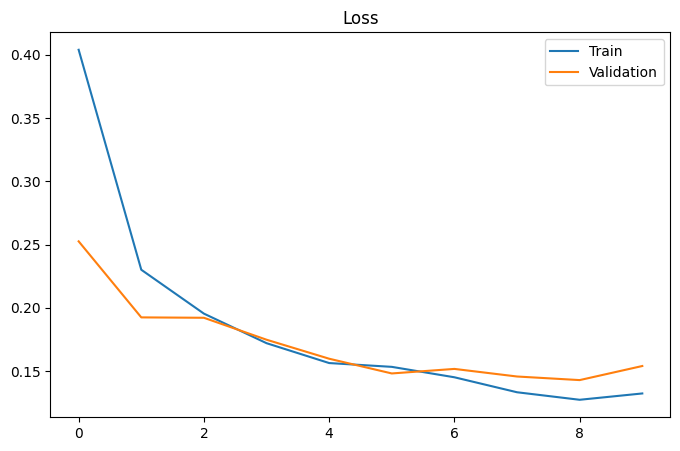

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 445ms/step


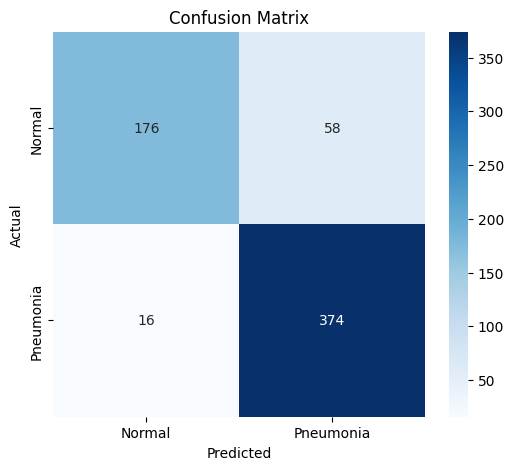


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       234
           1       0.87      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624


Model Saved Successfully ✅


In [ ]:
# ============================================
# ULTIMATE MEDICAL IMAGE CLASSIFICATION
# MobileNetV2 Transfer Learning
# ============================================

# ============================================
# 1. KAGGLE SETUP
# ============================================

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ============================================
# 2. DOWNLOAD DATASET
# ============================================

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --force

# ============================================
# 3. UNZIP
# ============================================

!unzip -q -o chest-xray-pneumonia.zip
!rm -rf __MACOSX

# ============================================
# 4. IMPORTS
# ============================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

# ============================================
# 5. PATHS
# ============================================

train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"

# ============================================
# 6. DATA GENERATORS
# ============================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

# TRAIN
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# VALIDATION
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# TEST
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ============================================
# 7. LOAD PRETRAINED MODEL
# ============================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# منع تدريب الطبقات الأساسية
base_model.trainable = False

# ============================================
# 8. BUILD FINAL MODEL
# ============================================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# ============================================
# 9. COMPILE MODEL
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# 10. CALLBACKS
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ============================================
# 11. TRAIN
# ============================================

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# ============================================
# 12. EVALUATION
# ============================================

test_loss, test_acc = model.evaluate(test_gen)

print("\n===== FINAL RESULTS =====")
print(f"Accuracy: {test_acc*100:.2f}%")
print(f"Loss: {test_loss:.4f}")

# ============================================
# 13. PLOTS
# ============================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ============================================
# 14. CONFUSION MATRIX
# ============================================

test_gen.reset()

preds = model.predict(test_gen)

y_pred = (preds > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Pneumonia'],
    yticklabels=['Normal','Pneumonia']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 15. CLASSIFICATION REPORT
# ============================================

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred))

# ============================================
# 16. SAVE MODEL
# ============================================

model.save("mobilenet_pneumonia.keras")

print("\nModel Saved Successfully ✅")